## TRANSEXPR STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

transexpr=pd.read_csv('../stock_data/transexpr.csv') ## so it can be small letter. This is cool.
transexpr=transexpr.drop(columns=['high_price','low_price'])
transexpr.rename(columns={'trade_date':'date'},inplace=True)
transexpr['date']=pd.to_datetime(transexpr['date'])
transexpr['month']=transexpr['date'].dt.month
transexpr['quarter']=transexpr['date'].dt.quarter
transexpr['year']=transexpr['date'].dt.year

transexpr

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42857,TRANSEXPR,2017-01-03,1.00,1.00,0.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43417,TRANSEXPR,2017-01-04,1.00,1.00,0.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43527,TRANSEXPR,2017-01-05,1.00,1.00,178000.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43637,TRANSEXPR,2017-01-06,1.00,1.00,47000.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43727,TRANSEXPR,2017-01-09,1.00,1.00,360583.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298141,TRANSEXPR,2026-07-13,3.35,3.35,687436.0,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298579,TRANSEXPR,2026-07-14,3.35,3.35,978020.0,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299017,TRANSEXPR,2026-07-15,3.02,3.02,1734877.0,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299455,TRANSEXPR,2026-07-16,3.02,3.02,275282.0,2026-07-16T15:10:03.113936+00:00,7,3,2026


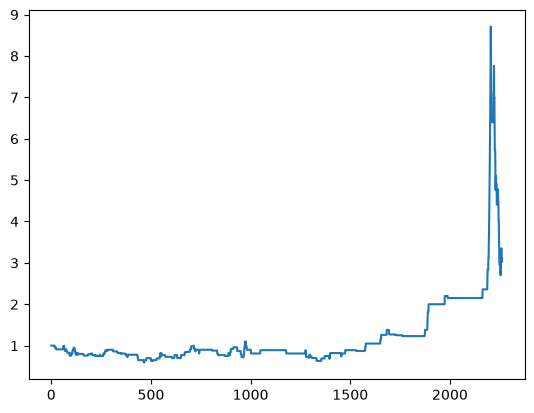

In [2]:
import matplotlib.pyplot as plt

plt.plot(transexpr['close_price'])
plt.show()

In [3]:
transexpr_end_month_df = (
    transexpr
    .sort_values("date")
    .groupby(transexpr["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

transexpr_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45427,TRANSEXPR,2017-01-31,0.95,0.95,20000.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47250,TRANSEXPR,2017-02-28,0.91,0.91,28100.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49366,TRANSEXPR,2017-03-31,0.99,0.99,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51193,TRANSEXPR,2017-04-28,0.83,0.83,15.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53116,TRANSEXPR,2017-05-31,0.81,0.81,87850.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35378,TRANSEXPR,2026-03-31,2.84,2.84,1953.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281204,TRANSEXPR,2026-04-30,6.40,6.40,354201.0,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284270,TRANSEXPR,2026-05-29,5.28,5.28,1018178.0,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294198,TRANSEXPR,2026-06-30,2.96,2.96,94065.0,2026-06-30T15:10:03.08168+00:00,6,2,2026


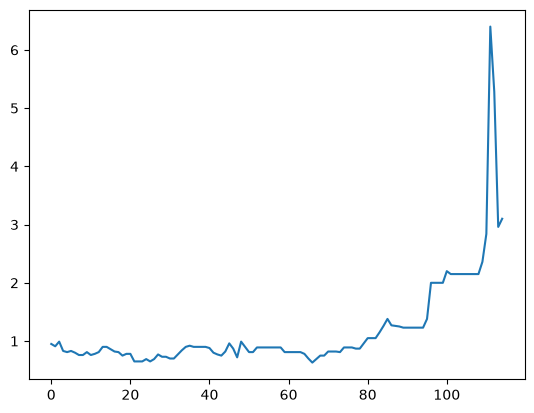

In [4]:
plt.plot(transexpr_end_month_df['close_price'])
plt.show()

In [5]:
transexpr_end_month_df['returns']=transexpr_end_month_df['close_price'].pct_change()*100
transexpr_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45427,TRANSEXPR,2017-01-31,0.95,0.95,20000.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47250,TRANSEXPR,2017-02-28,0.91,0.91,28100.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,-4.210526
2,49366,TRANSEXPR,2017-03-31,0.99,0.99,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,8.791209
3,51193,TRANSEXPR,2017-04-28,0.83,0.83,15.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,-16.161616
4,53116,TRANSEXPR,2017-05-31,0.81,0.81,87850.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,-2.409639
...,...,...,...,...,...,...,...,...,...,...,...
110,35378,TRANSEXPR,2026-03-31,2.84,2.84,1953.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,20.338983
111,281204,TRANSEXPR,2026-04-30,6.40,6.40,354201.0,2026-04-30T15:00:02.170664+00:00,4,2,2026,125.352113
112,284270,TRANSEXPR,2026-05-29,5.28,5.28,1018178.0,2026-05-29T15:00:02.455558+00:00,5,2,2026,-17.500000
113,294198,TRANSEXPR,2026-06-30,2.96,2.96,94065.0,2026-06-30T15:10:03.08168+00:00,6,2,2026,-43.939394


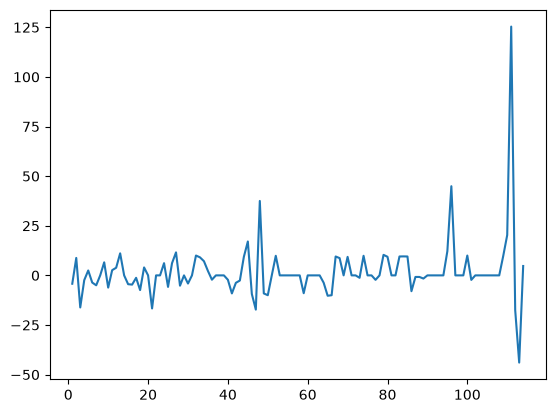

In [6]:
plt.plot(transexpr_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(transexpr_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.42242366113783), np.float64(5.457958543631802e-16), 1, 112, {'1%': np.float64(-3.4901313156261384), '5%': np.float64(-2.8877122815688776), '10%': np.float64(-2.5807296460459184)}, np.float64(833.666194662822))
stationary


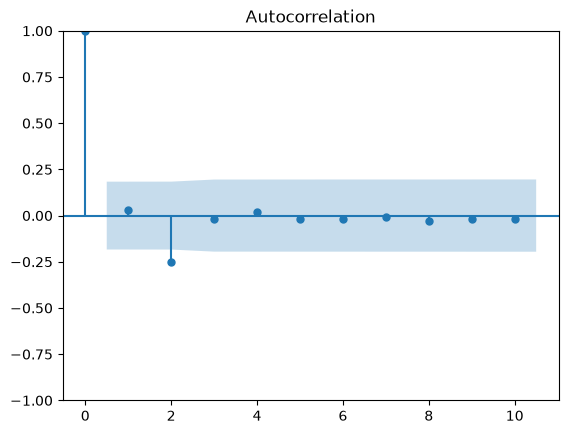

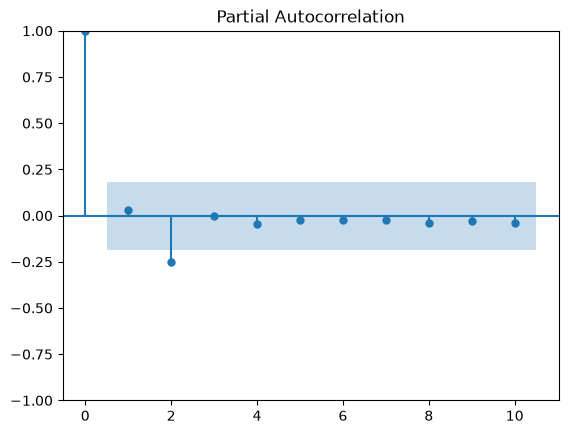

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(transexpr_end_month_df['returns'].dropna(), lags=10)
plot_pacf(transexpr_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=transexpr_end_month_df['close_price'][:-10]
test=transexpr_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -5.009414826438056]
[0, 0, 0, 0, 0, 1, -2.154387777695784]
[0, 0, 0, 0, 0, 2, -1.1132891065799453]
[0, 0, 0, 0, 1, 0, -0.6894114424182851]
[0, 0, 0, 0, 1, 1, -0.42102195736753956]
[0, 0, 0, 0, 1, 2, -0.17530882787590363]
[0, 0, 0, 0, 2, 0, 0.004932007325970655]
[0, 0, 0, 0, 2, 1, -0.0348651887992073]
[0, 0, 0, 0, 2, 2, 0.020994972265129586]
[0, 0, 0, 1, 0, 0, -0.7546223015812166]
[0, 0, 0, 1, 0, 1, -0.490843949730674]
[0, 0, 0, 1, 0, 2, -0.24234666004476635]
[0, 0, 0, 1, 1, 0, -0.20812155571288415]
[0, 0, 0, 1, 1, 1, -0.2071123612875152]
[0, 0, 0, 1, 1, 2, -0.23283382559159915]
[0, 0, 0, 1, 2, 0, -0.04143608607294125]
[0, 0, 0, 1, 2, 1, -0.005385883642995415]
[0, 0, 0, 1, 2, 2, -0.014418168022439115]
[0, 0, 0, 2, 0, 0, -0.33479192815802783]
[0, 0, 0, 2, 0, 1, -0.33536808414746]
[0, 0, 0, 2, 0, 2, -0.2943975824967666]
[0, 0, 0, 2, 1, 0, -0.20647865245449348]
[0, 0, 0, 2, 1, 1, -0.16930295262101902]
[0, 0, 0, 2, 1, 2, -0.2203231670527559]
[0, 0, 0, 2, 2, 0, 0.025191528

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-5.009415
27,0,0,1,0,0,0,-4.812995
54,0,0,2,0,0,0,-4.721711
55,0,0,2,0,0,1,-2.473304
1,0,0,0,0,0,1,-2.154388
...,...,...,...,...,...,...,...
222,0,2,2,0,2,0,0.251830
465,1,2,2,0,2,0,0.251959
681,2,2,1,0,2,0,0.252242
708,2,2,2,0,2,0,0.254003


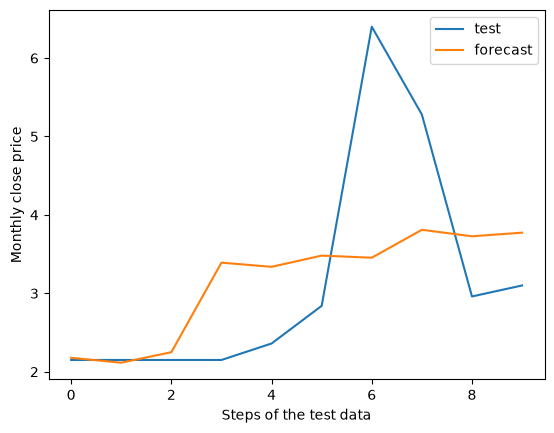

r2_score:  0.2546528077803699
rmse:  1.2165991269512364
description:  count    115.000000
mean       1.175304
std        0.825084
min        0.630000
25%        0.800000
50%        0.890000
75%        1.230000
max        6.400000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=transexpr_end_month_df['close_price'][:-10]
y_test=transexpr_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,2), 
seasonal_order=(0,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', transexpr_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=transexpr_end_month_df['returns'].dropna()[:-10]
test=transexpr_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.05570161654139616]
[0, 0, 0, 0, 0, 1, -0.05794586229393994]
[0, 0, 0, 0, 0, 2, -0.05741372922146781]
[0, 0, 0, 0, 1, 0, -0.19408799076304417]
[0, 0, 0, 0, 1, 1, -0.06814031451848424]
[0, 0, 0, 0, 1, 2, -0.07042772168275357]
[0, 0, 0, 0, 2, 0, -0.47821686872761426]
[0, 0, 0, 0, 2, 1, -0.2036733778739548]
[0, 0, 0, 0, 2, 2, -0.0650319549797147]
[0, 0, 0, 1, 0, 0, -0.05788028028468073]
[0, 0, 0, 1, 0, 1, -0.05758922650451237]
[0, 0, 0, 1, 0, 2, -0.05739368734308581]
[0, 0, 0, 1, 1, 0, -0.13009169156761868]
[0, 0, 0, 1, 1, 1, -0.06958203985494915]
[0, 0, 0, 1, 1, 2, -0.0588663863922787]
[0, 0, 0, 1, 2, 0, -0.36789854733941363]
[0, 0, 0, 1, 2, 1, -0.14472359907428567]
[0, 0, 0, 1, 2, 2, -0.15435890088423432]
[0, 0, 0, 2, 0, 0, -0.05734944874646697]
[0, 0, 0, 2, 0, 1, -0.05712683473391622]
[0, 0, 0, 2, 0, 2, -0.05333815450930102]
[0, 0, 0, 2, 1, 0, -0.08524942491846588]
[0, 0, 0, 2, 1, 1, -0.05563432313651262]
[0, 0, 0, 2, 1, 2, -0.02059056144902227]
[0, 0, 0, 2, 2, 0, 

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
167,0,2,0,0,1,2,-1.451452
222,0,2,2,0,2,0,-1.322514
427,1,2,0,2,1,1,-1.133118
653,2,2,0,0,2,0,-1.130301
184,0,2,0,2,1,1,-1.078954
...,...,...,...,...,...,...,...
374,1,1,1,2,1,2,0.012034
158,0,1,2,2,1,2,0.012070
131,0,1,1,2,1,2,0.012175
425,1,2,0,2,0,2,0.019512


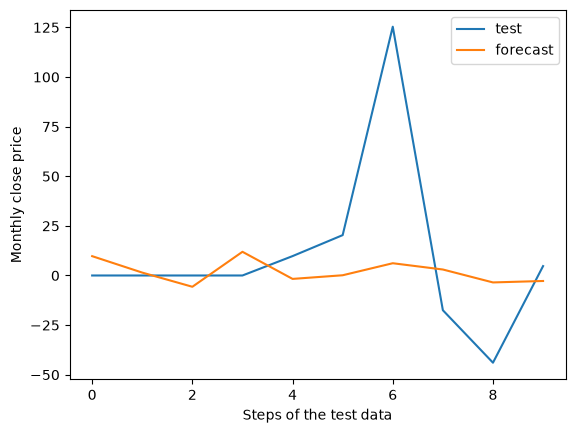

r2_score:  0.021583887347523367
rmse:  41.38662842646377
description:  count    114.000000
mean       1.883866
std       15.067844
min      -43.939394
25%       -2.240949
50%        0.000000
75%        4.547297
max      125.352113
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=transexpr_end_month_df['returns'].dropna()[:-10]
y_test=transexpr_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,2), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', transexpr_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
